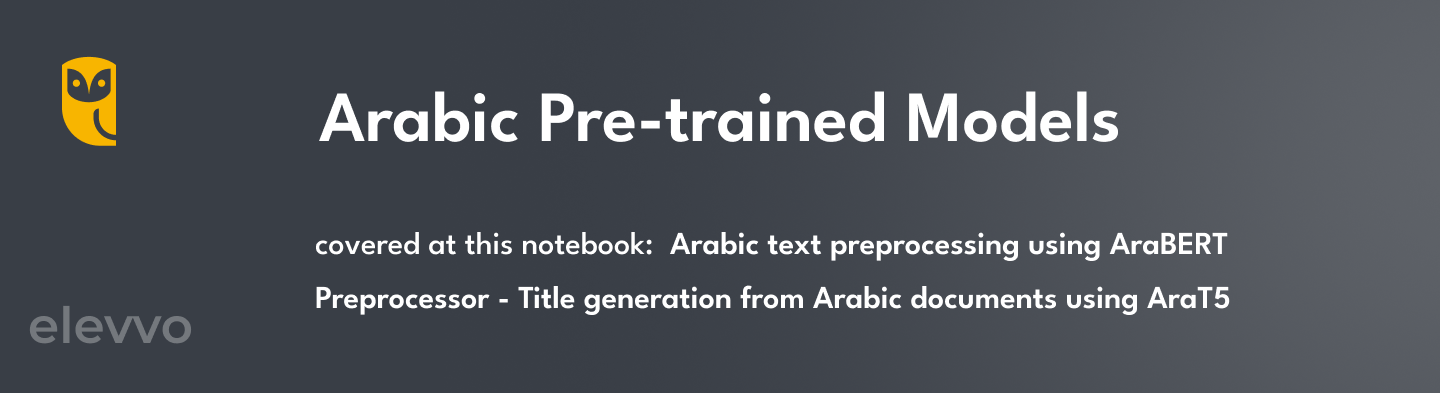

**AraT5 Title Generation Model**

📌 Using `AraT5` to generate titles for a given document

📌 `AraT5 is a pre-trained Arabic language model` based on the T5 (Text-to-Text Transfer Transformer) architecture, designed specifically for various Arabic NLP tasks like summarization, translation, and title generation by treating them all as text generation problems.

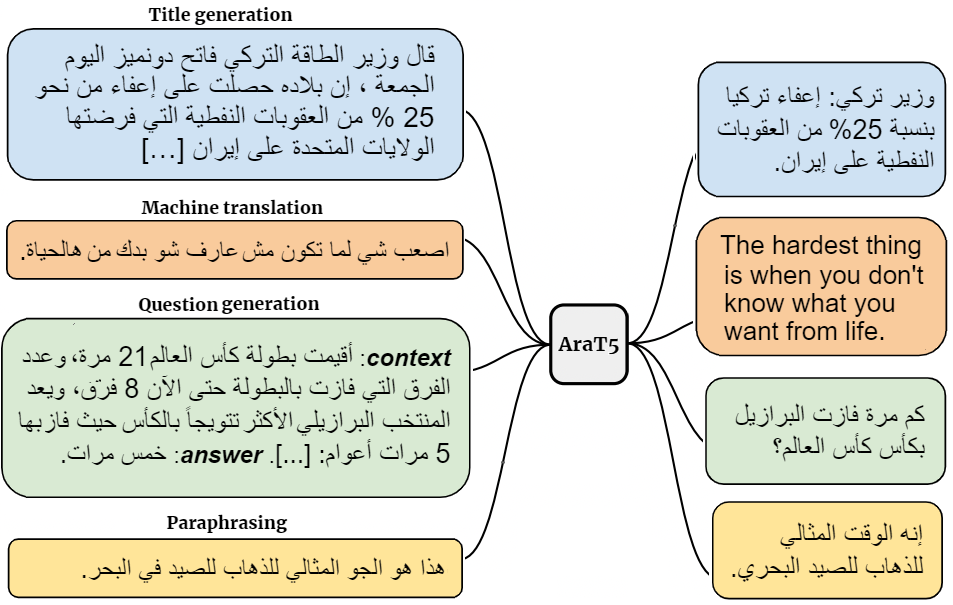

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
tokenizer = AutoTokenizer.from_pretrained("UBC-NLP/AraT5-base-title-generation")
model = AutoModelForSeq2SeqLM.from_pretrained("UBC-NLP/AraT5-base-title-generation")

Document = "تحت رعاية صاحب السمو الملكي الأمير سعود بن نايف بن عبدالعزيز أمير المنطقة الشرقية اختتمت غرفة الشرقية مؤخرا، الثاني من مبادرتها لتأهيل وتدريب أبناء وبنات المملكة ضمن مبادرتها المجانية للعام 2019 حيث قدمت 6 برامج تدريبية نوعية. وثمن رئيس مجلس إدارة الغرفة، عبدالحكيم العمار الخالدي، رعاية سمو أمير المنطقة الشرقية للمبادرة، مؤكدا أن دعم سموه لجميع أنشطة ."

encoding = tokenizer.encode_plus(Document,pad_to_max_length=True, return_tensors="pt")
input_ids, attention_masks = encoding["input_ids"], encoding["attention_mask"]


outputs = model.generate(
    input_ids=input_ids, attention_mask=attention_masks,
    max_length=256,
    do_sample=True,
    top_k=120,
    top_p=0.95,
    early_stopping=True,
    num_return_sequences=2
)

for id, output in enumerate(outputs):
    title = tokenizer.decode(output, skip_special_tokens=True,clean_up_tokenization_spaces=True)
    print("title#"+str(id), title)


title#0 سعود بن نايف يفتتح ثانى مبادرة لتدريب ابناء وبنات المملكة
title#1 غرفة الشرقية تختتم برنامج 'تدريب' أبناء وبنات المملكة


**AraBert Model**

📌 preprocessing text using AraBERT’s built-in preprocessor

In [ ]:
!pip install arabert

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 9.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for emoji: filename=emoji-1.4.2-py3-none-any.whl size=186459 sha256=093a0898570bb602a7b6d9fefb169f89f9d9424a282dd8ada95cbe542bff3605
  Stored in directory: /root/.cache/pip/wheels/10/f0/fd/4813b1177405693e8da9cdea839f0fb64fde161380e058c827
Successfully built emoji


📌 Parameters of ArabertPreprocessor:

1. `model_name`
2. `remove_html_markup` – clean HTML tags
3. `replace_urls_emails_mentions` – hide links and names
4. `strip_tashkeel` – remove diacritics
5. `strip_tatweel` – remove stretching chars
6. `insert_white_spaces` – space around punctuations

example:

🔹 Before:
أنااحبك!هل أنت بخير؟

🔹 After:
أنا احبك ! هل أنت بخير ؟

7. `remove_non_digit_repetition` – fix letter repetition
8. `keep_emojis`
9. `replace_slash_with_dash`
10. `map_hindi_numbers_to_arabic` – convert Hindi digits
11. `apply_farasa_segmentation` – split words properly

example:

🔹 Before: هلأنتبخير؟

🔹 After: هل أنت بخير ؟

In [ ]:
from arabert.preprocess import ArabertPreprocessor

model_name="bert-base-arabertv2"
arabert_prep = ArabertPreprocessor(model_name=model_name)

text = "ولن نبالغ إذا قلنا إن هاتف أو كمبيوتر المكتب في زمننا هذا ضروري"
arabert_prep.preprocess(text)

/usr/local/lib/python3.10/dist-packages/urllib3/connectionpool.py:1100: InsecureRequestWarning: Unverified HTTPS request is being made to host 'farasa-api.qcri.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


100%|██████████| 241M/241M [02:00<00:00, 2.00MiB/s]


[2024-05-08 07:16:27,126 - farasapy_logger - WARNING]: Be careful with large lines as they may break on interactive mode. You may switch to Standalone mode for such cases.


'و+ لن نبالغ إذا قل +نا إن هاتف أو كمبيوتر ال+ مكتب في زمن +نا هذا ضروري'